In [13]:
# %%
# nn.py

In [14]:
# %%
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import neural_network
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)

In [15]:
# %%
# Load the Breast Cancer dataset
bc_data = load_breast_cancer()
X = bc_data.data
y = bc_data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode the target
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# %%
# Apply clustering techniques
kmeans = KMeans(n_clusters=2, random_state=42)
X_train_kmeans = kmeans.fit_predict(X_train).reshape(-1, 1)
X_test_kmeans = kmeans.predict(X_test).reshape(-1, 1)

em = GaussianMixture(n_components=2, random_state=42)
X_train_em = em.fit_predict(X_train).reshape(-1, 1)
X_test_em = em.predict(X_test).reshape(-1, 1)

# Append cluster labels to the original features
X_train_kmeans = np.hstack((X_train, X_train_kmeans))
X_test_kmeans = np.hstack((X_test, X_test_kmeans))

X_train_em = np.hstack((X_train, X_train_em))
X_test_em = np.hstack((X_test, X_test_em))

In [17]:
# %%
# Train a neural network classifier
NeuralNetwork = neural_network.MLPClassifier(max_iter=3000, random_state=42)
param_grid = {
    "hidden_layer_sizes": np.arange(2, 50, 2),
    "activation": ["logistic", "relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [0.001, 0.01, 0.1],
    "learning_rate": ["invscaling", "adaptive"],
    "learning_rate_init": [0.001, 0.01, 0.1],
}


def fit_and_evaluate(X_train, X_test, y_train, y_test, method_name):
    NeuralNetworkCV = GridSearchCV(
        NeuralNetwork, param_grid, cv=5, n_jobs=-1, verbose=0
    )

    start_time = time.time()
    NeuralNetworkCV.fit(X_train, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    print(f"Training time ({method_name}): {training_time:.2f} seconds")
    print(f"Best parameters ({method_name}): {NeuralNetworkCV.best_params_}")

    NeuralNetworkCV.predict(X_train)
    y_test_pred = NeuralNetworkCV.predict(X_test)

    train_score = NeuralNetworkCV.score(X_train, y_train)
    test_score = NeuralNetworkCV.score(X_test, y_test)
    print(f"Train accuracy ({method_name}): {train_score:.4f}")
    print(f"Test accuracy ({method_name}): {test_score:.4f}")

    precision = precision_score(y_test, y_test_pred, average="weighted")
    recall = recall_score(y_test, y_test_pred, average="weighted")
    f1 = f1_score(y_test, y_test_pred, average="weighted")
    roc_auc = roc_auc_score(y_test, y_test_pred, average="weighted")

    print(f"Precision ({method_name}): {precision:.4f}")
    print(f"Recall ({method_name}): {recall:.4f}")
    print(f"F1 Score ({method_name}): {f1:.4f}")
    print(f"ROC AUC Score ({method_name}): {roc_auc:.4f}")

    cm = confusion_matrix(y_test.argmax(axis=1), y_test_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="viridis")
    plt.title(f"Confusion Matrix ({method_name})")
    plt.savefig(f"./result/confusion_matrix_{method_name.lower()}.png")
    plt.show()

    BestNeuralNetwork = NeuralNetworkCV.best_estimator_
    train_sizes, train_scores, test_scores = learning_curve(
        BestNeuralNetwork,
        X_train,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 20),
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    return (
        train_sizes,
        train_scores_mean,
        train_scores_std,
        test_scores_mean,
        test_scores_std,
        NeuralNetworkCV.best_estimator_,
        train_score,
        test_score,
        training_time,
        precision,
        recall,
        f1,
        roc_auc,
    )

Training time (Original): 233.57 seconds
Best parameters (Original): {'activation': 'logistic', 'alpha': 0.1, 'hidden_layer_sizes': np.int64(42), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (Original): 0.9824
Test accuracy (Original): 0.9912
Precision (Original): 0.9913
Recall (Original): 0.9912
F1 Score (Original): 0.9912
ROC AUC Score (Original): 0.9884


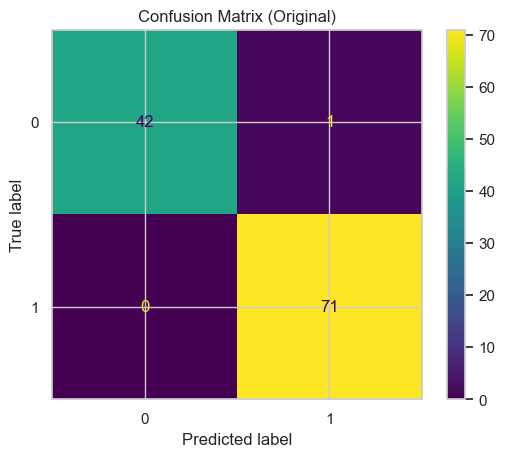

Training time (KMeans): 234.61 seconds
Best parameters (KMeans): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': np.int64(10), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'solver': 'sgd'}
Train accuracy (KMeans): 0.9868
Test accuracy (KMeans): 0.9825
Precision (KMeans): 0.9825
Recall (KMeans): 0.9825
F1 Score (KMeans): 0.9825
ROC AUC Score (KMeans): 0.9813


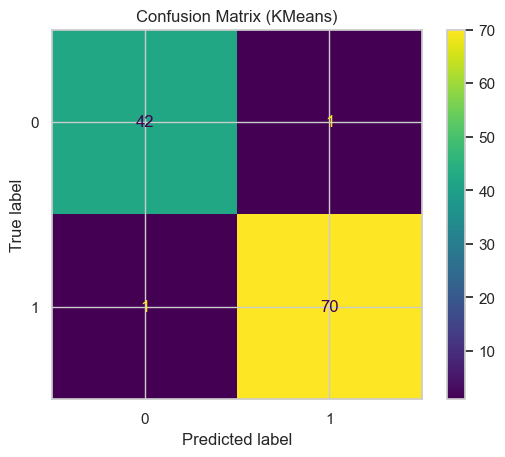

In [18]:
# %%
# Evaluate on original data
(
    train_sizes_original,
    train_scores_mean_original,
    train_scores_std_original,
    test_scores_mean_original,
    test_scores_std_original,
    best_nn_original,
    train_score_original,
    test_score_original,
    training_time_original,
    precision_original,
    recall_original,
    f1_original,
    roc_auc_original,
) = fit_and_evaluate(X_train, X_test, y_train, y_test, "Original")

# Evaluate on KMeans data
(
    train_sizes_kmeans,
    train_scores_mean_kmeans,
    train_scores_std_kmeans,
    test_scores_mean_kmeans,
    test_scores_std_kmeans,
    best_nn_kmeans,
    train_score_kmeans,
    test_score_kmeans,
    training_time_kmeans,
    precision_kmeans,
    recall_kmeans,
    f1_kmeans,
    roc_auc_kmeans,
) = fit_and_evaluate(X_train_kmeans, X_test_kmeans, y_train, y_test, "KMeans")

Training time (EM): 235.55 seconds
Best parameters (EM): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': np.int64(4), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'solver': 'sgd'}
Train accuracy (EM): 0.9846
Test accuracy (EM): 0.9825
Precision (EM): 0.9825
Recall (EM): 0.9825
F1 Score (EM): 0.9825
ROC AUC Score (EM): 0.9813


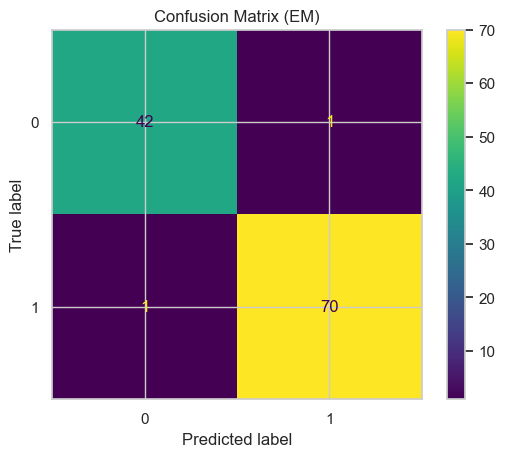

In [20]:
# Evaluate on EM data
(
    train_sizes_em,
    train_scores_mean_em,
    train_scores_std_em,
    test_scores_mean_em,
    test_scores_std_em,
    best_nn_em,
    train_score_em,
    test_score_em,
    training_time_em,
    precision_em,
    recall_em,
    f1_em,
    roc_auc_em,
) = fit_and_evaluate(X_train_em, X_test_em, y_train, y_test, "EM")

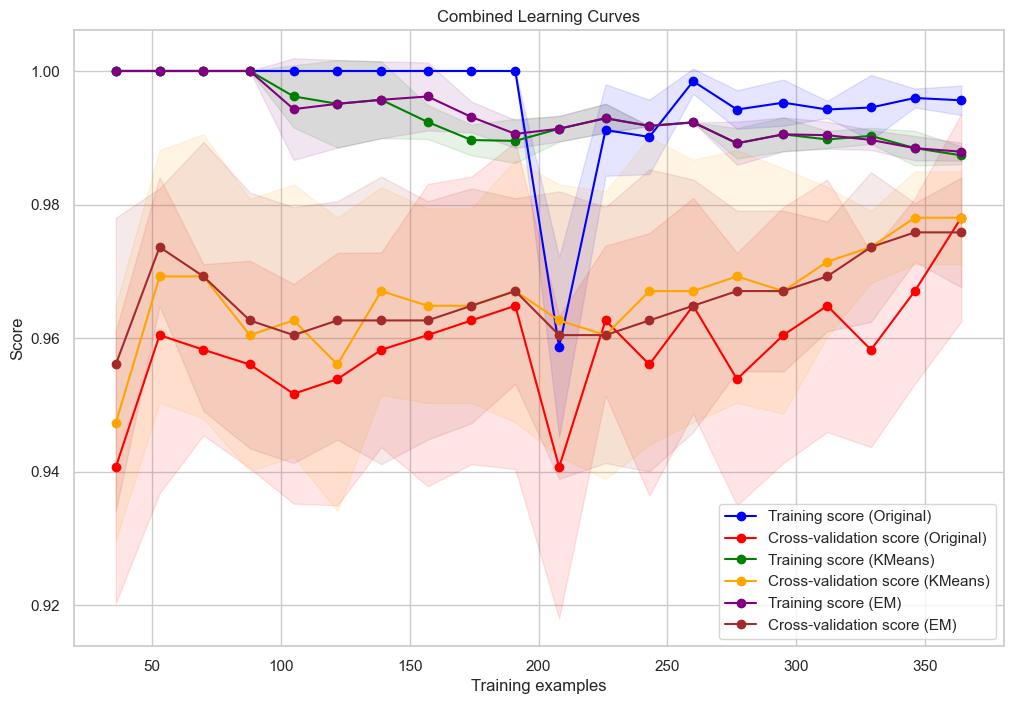

In [21]:
# %%
# Combine learning curve plots
plt.figure(figsize=(12, 8))

# Original data learning curve
plt.fill_between(
    train_sizes_original,
    train_scores_mean_original - train_scores_std_original,
    train_scores_mean_original + train_scores_std_original,
    alpha=0.1,
    color="blue",
)
plt.fill_between(
    train_sizes_original,
    test_scores_mean_original - test_scores_std_original,
    test_scores_mean_original + test_scores_std_original,
    alpha=0.1,
    color="red",
)
plt.plot(
    train_sizes_original,
    train_scores_mean_original,
    "o-",
    color="blue",
    label="Training score (Original)",
)
plt.plot(
    train_sizes_original,
    test_scores_mean_original,
    "o-",
    color="red",
    label="Cross-validation score (Original)",
)

# KMeans data learning curve
plt.fill_between(
    train_sizes_kmeans,
    train_scores_mean_kmeans - train_scores_std_kmeans,
    train_scores_mean_kmeans + train_scores_std_kmeans,
    alpha=0.1,
    color="green",
)
plt.fill_between(
    train_sizes_kmeans,
    test_scores_mean_kmeans - test_scores_std_kmeans,
    test_scores_mean_kmeans + test_scores_std_kmeans,
    alpha=0.1,
    color="orange",
)
plt.plot(
    train_sizes_kmeans,
    train_scores_mean_kmeans,
    "o-",
    color="green",
    label="Training score (KMeans)",
)
plt.plot(
    train_sizes_kmeans,
    test_scores_mean_kmeans,
    "o-",
    color="orange",
    label="Cross-validation score (KMeans)",
)

# EM data learning curve
plt.fill_between(
    train_sizes_em,
    train_scores_mean_em - train_scores_std_em,
    train_scores_mean_em + train_scores_std_em,
    alpha=0.1,
    color="purple",
)
plt.fill_between(
    train_sizes_em,
    test_scores_mean_em - test_scores_std_em,
    test_scores_mean_em + test_scores_std_em,
    alpha=0.1,
    color="brown",
)
plt.plot(
    train_sizes_em,
    train_scores_mean_em,
    "o-",
    color="purple",
    label="Training score (EM)",
)
plt.plot(
    train_sizes_em,
    test_scores_mean_em,
    "o-",
    color="brown",
    label="Cross-validation score (EM)",
)

plt.title("Combined Learning Curves")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.savefig("./result/combined_learning_curve.png")
plt.show()

In [22]:
# %%
# Compile results into a DataFrame
results = {
    "Method": ["Original", "KMeans", "EM"],
    "Train Accuracy": [
        train_score_original,
        train_score_kmeans,
        train_score_em,
    ],
    "Test Accuracy": [
        test_score_original,
        test_score_kmeans,
        test_score_em,
    ],
    "Training Time (s)": [
        training_time_original,
        training_time_kmeans,
        training_time_em,
    ],
    "Precision": [
        precision_original,
        precision_kmeans,
        precision_em,
    ],
    "Recall": [
        recall_original,
        recall_kmeans,
        recall_em,
    ],
    "F1 Score": [
        f1_original,
        f1_kmeans,
        f1_em,
    ],
    "ROC AUC Score": [
        roc_auc_original,
        roc_auc_kmeans,
        roc_auc_em,
    ],
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_excel("./result/nn_performance_comparison.xlsx", index=False)

print("Results saved to './result/nn_performance_comparison.xlsx'")

     Method  Train Accuracy  Test Accuracy  Training Time (s)  Precision  \
0  Original        0.982418       0.991228         233.568548   0.991350   
1    KMeans        0.986813       0.982456         234.609408   0.982456   
2        EM        0.984615       0.982456         235.549438   0.982456   

     Recall  F1 Score  ROC AUC Score  
0  0.991228  0.991207       0.988372  
1  0.982456  0.982456       0.981330  
2  0.982456  0.982456       0.981330  
Results saved to './result/nn_performance_comparison.xlsx'


In [ ]:
# %%